7.959677386708116


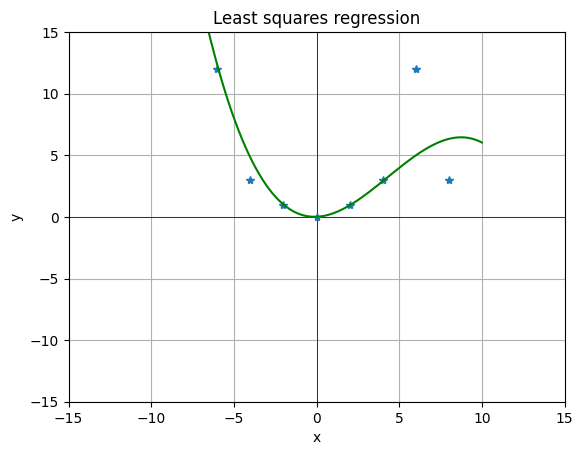

Finished.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def gradient_descent(f, df, x0, step_size_fn, max_iter):
    """
    Performs gradient descent on the given function f, with its gradient df.

    :param f: A function whose input is an x, a column vector, and returns a scalar.
    :param df: A function whose input is an x, a column vector, and returns a column vector representing the gradient of f at x.
    :param x0: An initial value of x, x0, which is a column vector.
    :param step_size: The step size to use in each step
    :param max_iter: The number of iterations to perform

    :return x: the value at the final step
    :return fs: the list of values of f found during all the iterations (including f(x0))
    :return xs: the list of values of x found during all the iterations (including x0)
    """

    # Exercise 1 (d): Todo: Implement here.
    x = x0
    fs = []
    xs = []

    for i in range(max_iter):
      f_val = f(x)
      grad = df(x)

      fs.append(f_val)
      xs.append(x)

      x = x - step_size_fn(i) * grad

    return x, fs, xs


def transform_polynomial_basis_1d(x, order):
    """
    Transforms a single 1-dimensional data point x with a polynomial basis transformation.

    :param x: A numpy array with a single value (d=1).
    :param order: Can be 0, 1, 2 or 3.
    :return: The transformed data point x as a list.
    """
    if order==0:
        return [1]
    if order==1:
        return [1, x]
    if order==2:
        # Todo: Implement the polynomial basis for k=2:
        return [1, x, x ** 2]                     # 1.4 b i)
    if order==3:
        # Todo: And for k=3:
        return [1, x, x ** 2, x ** 3]                     # 1.4 b i)


def data_linear_trivial():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    return X, Y


def data_linear_simple():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-5], [-5], [-3], [1], [2], [5], [6]])
    return X, Y


def data_linear_offset():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]]) + 6
    return X, Y


def data_quadratic():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[12], [3], [1], [0], [1], [3], [12]])
    return X, Y


def data_polynomial():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6], [8]])
    Y = np.array([[12], [3], [1], [0], [1], [3], [12], [3]])
    return X, Y


def plot_line_2d(axes, theta, line_style, xmin=-10, xmax=10):
    """
    Takes a 2-dimensional theta and plots the line defined by (theta[1], theta[0]) into the given axes.
    """
    p1_y = theta[0] * xmin + theta[1]
    p2_y = theta[0] * xmax + theta[1]
    ax.plot([xmin, xmax], [p1_y.flatten(), p2_y.flatten()], line_style)


if __name__ == '__main__':
    """
    We'll implement gradient descent, and test it on a simple quadratic function. We'll go on implementing the
    closed-form OLS solution, as well as solving the OLS objective with gradient descent, with various provided data.
    We'll analyse the convergence of gradient descent with various step sizes, and plot the loss (convergence plot).
    The final exercise uses polynomial basis transformation to fit more complex data with linear hypotheses.
    """

    # Exercise 1: Gradient descent to find the minimum of a simple quadratic function
    # -----------
    #def f1(x):
    #    # Our function is f(x) = (3x+4)^2
    #    return float((3 * x + 4) ** 2)

    #def df1(x):
    #    # 1 (c): Todo: Implement the derivative here
    #    return float(18 * x + 24)

    ## 1 (e): Todo: Plot the function:
    #fig_simple, ax_simple = plt.subplots()  # create an empty plot and retrieve the 'ax' handle
    #
    #f1_x = np.linspace(-10, 10, 100)
    #f1_f = [f1(x) for x in f1_x]
    #ax_simple.plot(f1_x, f1_f)


    ## Todo: Set and plot the initial value:
    #x0 = 0
    #ax_simple.plot(x0, f1(x0), 'ro')


    ## Run gradient descent to find the minimum of the function:
    ## Todo: Experiment with step size, max_iter
    #last_x, fs, xs = gradient_descent(f1, df1, x0, step_size_fn=lambda i: 0.001, max_iter=100)
    ## Todo: Plot the found 'x' value and f(x)


    ## Todo: Plot each step of gradient descent, to see how it converges/diverges
    #for x_val, f_val in zip(xs, fs):
    #    ax_simple.plot(x_val, f_val, 'bx')

    #ax_simple.plot(last_x, f1(last_x), 'go')
    #plt.show(block=True)
    # -----------

    # Exercise 2: Least Squares Regression
    # -----------
    # Get some example data (browse the file to see the various data_* functions provided):
    #X, Y = data_linear_trivial()  ## 1.2 i)

    #X, Y =     data_linear_offset()                        ## 1.2 iv)
    #X, Y = data_quadratic()
    X, Y = data_polynomial()
    #X_augmented = np.insert(X, 1, [1], axis=1) ## 1.2 i), see ppt ##
    X_augmented = np.array([transform_polynomial_basis_1d(x[0], 3) for x in X])     ## 1.4 ii)
    #theta_star = np.linalg.inv(X_augmented.T @ X_augmented) @ X_augmented.T @ Y ## 1.2 ii), see ppt ##




    # Create a plot and set up some default plot options:
    fig, ax = plt.subplots()
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.grid(True, which='both')
    ax.axhline(color='black', linewidth=0.5)
    ax.axvline(color='black', linewidth=0.5)
    ax.set_title("Least squares regression")
    # Todo: Plot the data here (ex. 2.2)
    # ...
    ## --------------------------------------         1.2 iii)
    ax.plot(X, Y, '*')
    #plot_line_2d(axes, theta, line_style, xmin=-10, xmax=10)
    #plot_line_2d(ax, theta_star, 'g-')
    #plt.show(block=True)
    ## --------------------------------------         1.2 iii)



    # Todo: Feature transformation, add column of ones
    #X_augmented = np.insert(X, 1, [1], axis=1)                 ## 1.3 ii)##

    # Exercise 2.2: Todo: Compute theta* using the analytical OLS solution:
    # ------------
    # theta_star = np.zeros(X_augmented.shape[1],1)              ## 1.3 ii)##

    # Todo: Plot the resulting hypothesis into the plot:
    # plot_line_2d(...)

    # Exercise 2.3 - Solution using gradient descent:
    # ------------


    ## ------------------------------------------  ## 1.3 i)  see ppt
    # Todo: Implement the loss function:
    def squared_loss(x, y, theta):
        return (y-x @ theta) ** 2

    # Todo: Implement the OLS objective function (using the loss):
    def ols_objective(X, Y, theta):
        return np.mean(squared_loss(X, Y, theta))

    # Todo: Implement the partial derivative of the squared loss w.r.t. theta
    def d_squared_loss_theta(x, y, theta):
        return (2/x.shape[1]) * x.T @ (x @ theta - y)

    # Todo: Implement the partial derivative of the OLS objective w.r.t. theta (using the partial derivative of the squared loss):
    def d_ols_objective_theta(x, y, theta):
        return d_squared_loss_theta(x, y, theta)

    ## ------------------------------------------  ## 1.3 i)

    # Finally, the gradient of our OLS objective is simply d_ols_objective_theta (as theta is our only parameter):
    def ols_objective_grad(X, Y, theta):
        return d_ols_objective_theta(X, Y, theta)

    # And we define the function that we want to minimise as the OLS objective over our dataset (X_augmented, Y):
    def f_ols(theta):
        return ols_objective(X_augmented, Y, theta)

    # And its gradient:
    def df_ols(theta):
        return ols_objective_grad(X_augmented, Y, theta)

    # Todo: Set an initial value for theta_init:
    theta_init = np.zeros((X_augmented.shape[1],1))              ## 1.3 ii)##

    # We define a step size function - let's return a constant step size, independent of the iteration i:
    def step_size_fn(i):                                       ## 1.3 ii)##
        return 0.00001  # Todo: Experiment with various step sizes
    # Now we're ready to run gradient descent to minimise f_ols:
    last_x, fs, xs = gradient_descent(f_ols, df_ols, theta_init, step_size_fn=step_size_fn, max_iter=500)

    print(ols_objective(X_augmented, Y, last_x)) # MSE


    ## ----------------------------------------------------------1.4 b iii)##
    x_plot = np.linspace(-10, 10, 201)
    y_plot = []
    for x_p in x_plot:
      x_aug = np.array(transform_polynomial_basis_1d(x_p,3))
      y_plot.append(last_x.T @ x_aug)

    ax.plot(x_plot, y_plot, 'g-')
    plt.show(block=True)
    ## ----------------------------------------------------------1.4 b iii)##


    # Todo: Plot the found hypothesis into the figure with the data.
    # Todo: Also plot individual steps of gradient descent, to see how the optimisation behaves.
    # plot_line_2d(...)
    # ...
    #plot_line_2d(ax, last_x, 'g-')                     ## 1.3 ii)##
    #plt.show(block=True)

    # Exercise 2.3 iii):
    #fig_loss, ax_loss = plt.subplots()  # Create an empty figure for the loss plot
    # Todo: Plot the loss over the iterations
    # ... ax_loss.plot(...) ...

    #ax_loss.plot(range(len(fs)),fs)                  ## 1.3 iii)##
    #plt.show(block=True)

    # Optional: Exercise 2.4
    # Ex. 2.4 (b) iii): Plot the polynomial separator in 2D:
    # ...

    print("Finished.")

# Q1.2 (iii)

theta* = [1. 0.]  →  slope=1.0000, intercept=0.0000


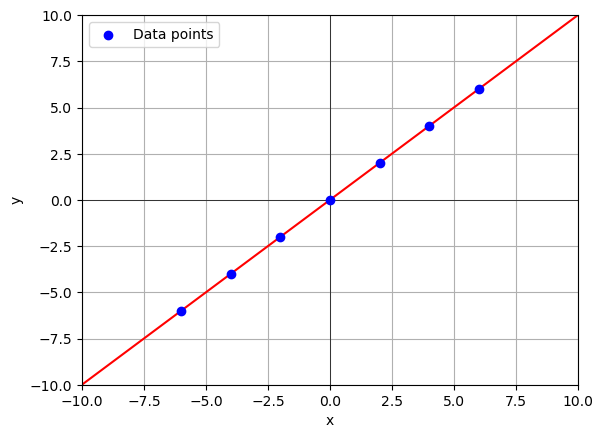

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data functions
def data_linear_trivial():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    return X, Y

def plot_line_2d(ax, theta, line_style, xmin=-10, xmax=10):
    p1_y = theta[0] * xmin + theta[1]
    p2_y = theta[0] * xmax + theta[1]
    ax.plot([xmin, xmax], [float(np.array(p1_y).flat[0]), float(np.array(p2_y).flat[0])], line_style)

# Load data and augment X
X, Y = data_linear_trivial()
X_augmented = np.hstack([X, np.ones((X.shape[0], 1))])

# Compute theta* (closed-form OLS)
theta_star = np.linalg.inv(X_augmented.T @ X_augmented) @ X_augmented.T @ Y
print(f"theta* = {theta_star.flatten()}  →  slope={theta_star[0,0]:.4f}, intercept={theta_star[1,0]:.4f}")

# Plot data and fitted line
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.grid(True, which='both')
ax.axhline(color='black', linewidth=0.5)
ax.axvline(color='black', linewidth=0.5)

# Plot original data points (NOT augmented)
ax.scatter(X, Y, color='blue', zorder=5, label='Data points')

plot_line_2d(ax, theta_star, 'r-')

ax.legend()
plt.show()

# Q1.2 (iv)

theta* = [1. 6.]  →  slope=1.0000, intercept=6.0000


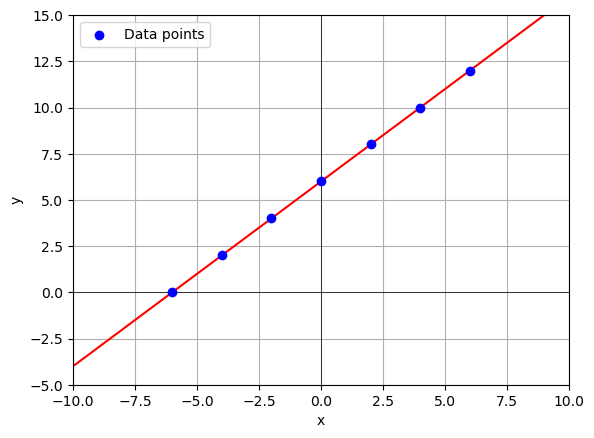

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def data_linear_offset():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]]) + 6
    return X, Y

def plot_line_2d(ax, theta, line_style, xmin=-10, xmax=10):
    p1_y = theta[0] * xmin + theta[1]
    p2_y = theta[0] * xmax + theta[1]
    ax.plot([xmin, xmax], [float(np.array(p1_y).flat[0]), float(np.array(p2_y).flat[0])], line_style)

# ── Load data ──
X, Y = data_linear_offset()

# ── 1.2 (i): Augment X with column of ones ──
X_augmented = np.hstack([X, np.ones((X.shape[0], 1))])

# ── 1.2 (ii): Compute theta* ──
theta_star = np.linalg.inv(X_augmented.T @ X_augmented) @ X_augmented.T @ Y
print(f"theta* = {theta_star.flatten()}  →  slope={theta_star[0,0]:.4f}, intercept={theta_star[1,0]:.4f}")

# ── 1.2 (iii)/(iv): Plot ──
fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10, 10)
ax.set_ylim(-5, 15)
ax.grid(True, which='both')
ax.axhline(color='black', linewidth=0.5)
ax.axvline(color='black', linewidth=0.5)

# Plot original data points (NOT augmented)
ax.scatter(X, Y, color='blue', zorder=5, label='Data points')

# Plot the fitted line
plot_line_2d(ax, theta_star, 'r-')

ax.legend()
plt.show()

# Q1.3 (ii)

step=0.01, iter=200 → θ=[1. 0. 1. 0.], loss=8.500000


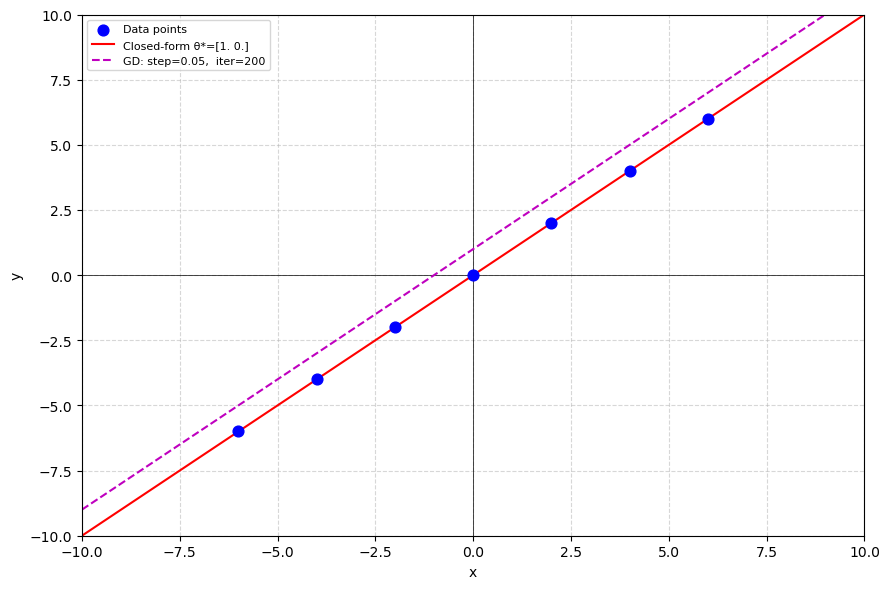

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Data
def data_linear_trivial():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    return X, Y

def plot_line_2d(ax, theta, line_style, label=None, xmin=-10, xmax=10):
    p1_y = theta[0] * xmin + theta[1]
    p2_y = theta[0] * xmax + theta[1]
    ax.plot([xmin, xmax],
            [float(np.array(p1_y).flat[0]), float(np.array(p2_y).flat[0])],
            line_style, label=label)

# Gradient Descent
def gradient_descent(f, df, x0, step_size_fn, max_iter):
    x = x0
    xs = [x0]
    fs = [f(x0)]
    for i in range(max_iter):
        x = x - step_size_fn(i) * df(x)
        xs.append(x)
        fs.append(f(x))
    return x, fs, xs

# Loss functions
def squared_loss(x, y, theta):
    return (np.dot(theta.T, x) - y) ** 2

def ols_objective(X, Y, theta):
    return np.mean([squared_loss(X[i], Y[i], theta) for i in range(len(X))])

def d_squared_loss_theta(x, y, theta):
    return 2 * (np.dot(theta.T, x) - y) * x

def d_ols_objective_theta(X, Y, theta):
    return np.mean([d_squared_loss_theta(X[i], Y[i], theta) 
                    for i in range(len(X))], axis=0)

# Setup
X, Y = data_linear_trivial()
X_augmented = np.hstack([X, np.ones((X.shape[0], 1))])

# Closed-form theta* for comparison
theta_star = np.linalg.inv(X_augmented.T @ X_augmented) @ X_augmented.T @ Y

# Wrappers for gradient descent
def f_ols(theta):
    return ols_objective(X_augmented, Y, theta)

def df_ols(theta):
    return d_ols_objective_theta(X_augmented, Y, theta)

# Experiment with different step sizes
configs = [
    (0.01,   200,  'm--',  'GD: step=0.05,  iter=200'),
]

theta_init = np.array([[0.0], [0.0]])   # start at zero

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(color='black', linewidth=0.5)
ax.axvline(color='black', linewidth=0.5)

# Plot data points
ax.scatter(X, Y, color='blue', zorder=5, s=60, label='Data points')

# Plot closed-form solution
plot_line_2d(ax, theta_star, 'r-', label=f'Closed-form θ*={theta_star.flatten().round(3)}')

# Plot GD solutions
for step, iters, style, label in configs:
    theta_gd, fs, xs = gradient_descent(
        f_ols, df_ols, theta_init,
        step_size_fn=lambda i, s=step: s,
        max_iter=iters
    )
    print(f"step={step}, iter={iters} → θ={theta_gd.flatten().round(4)}, "
          f"loss={f_ols(theta_gd):.6f}")
    plot_line_2d(ax, theta_gd, style, label=label)

ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Q1.3 (iii)

step=0.001: initial loss=16.0000, final loss=8.498523
step=0.01: initial loss=16.0000, final loss=8.500000
step=0.05: initial loss=16.0000, final loss=8.500000


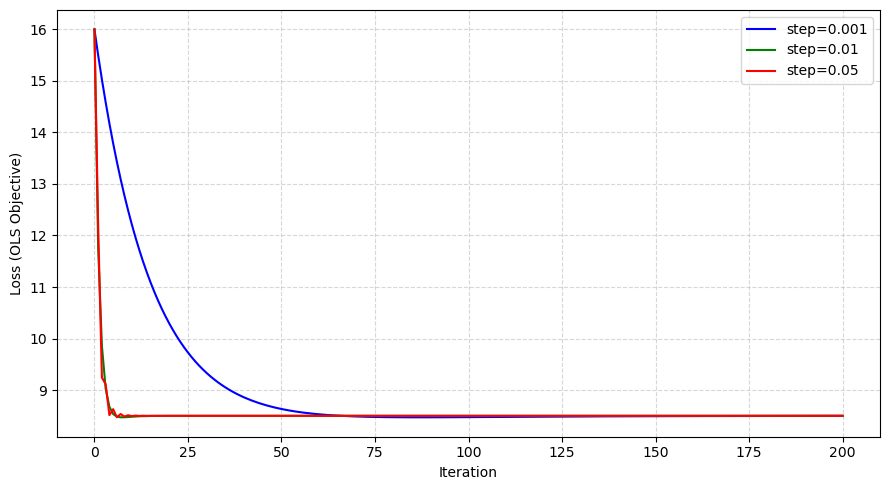

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──
def data_linear_trivial():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    return X, Y

# ── Gradient Descent ──
def gradient_descent(f, df, x0, step_size_fn, max_iter):
    x = x0
    xs = [x0]
    fs = [f(x0)]
    for i in range(max_iter):
        x = x - step_size_fn(i) * df(x)
        xs.append(x)
        fs.append(f(x))
    return x, fs, xs

# ── Loss functions ──
def squared_loss(x, y, theta):
    return (np.dot(theta.T, x) - y) ** 2

def ols_objective(X, Y, theta):
    return np.mean([squared_loss(X[i], Y[i], theta) for i in range(len(X))])

def d_squared_loss_theta(x, y, theta):
    return 2 * (np.dot(theta.T, x) - y) * x

def d_ols_objective_theta(X, Y, theta):
    return np.mean([d_squared_loss_theta(X[i], Y[i], theta)
                    for i in range(len(X))], axis=0)

# ── Setup ──
X, Y = data_linear_trivial()
X_augmented = np.hstack([X, np.ones((X.shape[0], 1))])

def f_ols(theta):
    return ols_objective(X_augmented, Y, theta)

def df_ols(theta):
    return d_ols_objective_theta(X_augmented, Y, theta)

theta_init = np.array([[0.0], [0.0]])

# ── Run GD with different step sizes ──
configs = [
    (0.001, 200, 'b-',  'step=0.001'),
    (0.01,  200, 'g-',  'step=0.01'),
    (0.05,  200, 'r-',  'step=0.05'),
]

# ── Convergence Plot ──
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (OLS Objective)')
ax.grid(True, linestyle='--', alpha=0.5)

for step, iters, style, label in configs:
    _, fs, _ = gradient_descent(
        f_ols, df_ols, theta_init,
        step_size_fn=lambda i, s=step: s,
        max_iter=iters
    )
    # fs contains the loss at every iteration (including iteration 0)
    ax.plot(range(len(fs)), fs, style, label=label)
    print(f"step={step}: initial loss={fs[0]:.4f}, final loss={float(np.array(fs[-1]).flat[0]):.6f}")

ax.legend()
plt.tight_layout()
plt.show()

# Q1.4(a)

theta*    : slope=0.0000,  intercept=4.5714
MSE       : 23.1020
Fitted line: y = 0.0000x + 4.5714


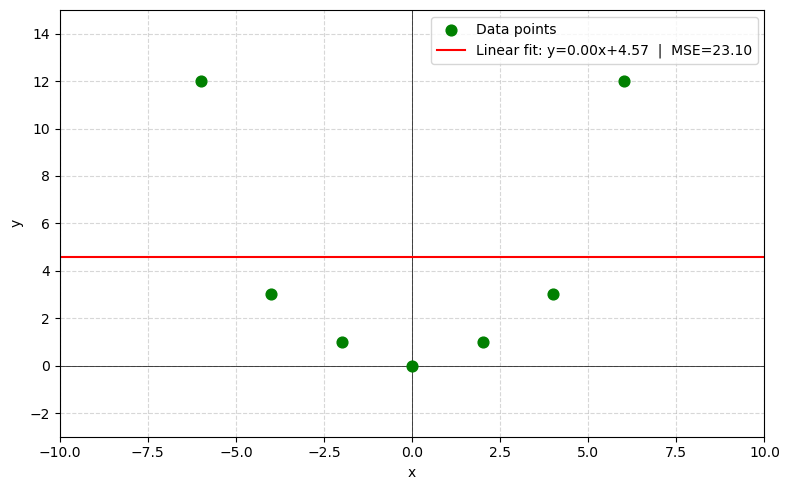

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Data
def data_quadratic():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[12], [3], [1], [0], [1], [3], [12]])
    return X, Y

def plot_line_2d(ax, theta, line_style, label=None, xmin=-10, xmax=10):
    p1_y = theta[0] * xmin + theta[1]
    p2_y = theta[0] * xmax + theta[1]
    ax.plot([xmin, xmax],
            [float(np.array(p1_y).flat[0]), float(np.array(p2_y).flat[0])],
            line_style, label=label)

# OLS closed-form
def ols_closed_form(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

# MSE
def mse(X, Y, theta):
    predictions = X @ theta          # shape (n, 1)
    residuals   = predictions - Y    # shape (n, 1)
    return float(np.mean(residuals ** 2))

# Setup
X, Y = data_quadratic()

# Augment X with column of ones
X_augmented = np.hstack([X, np.ones((X.shape[0], 1))])

# Compute theta*
theta_star = ols_closed_form(X_augmented, Y)
slope     = float(theta_star[0].flat[0])
intercept = float(theta_star[1].flat[0])

# Compute MSE
mse_value = mse(X_augmented, Y, theta_star)

print(f"theta*    : slope={slope:.4f},  intercept={intercept:.4f}")
print(f"MSE       : {mse_value:.4f}")
print(f"Fitted line: y = {slope:.4f}x + {intercept:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-10, 10)
ax.set_ylim(-3, 15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(color='black', linewidth=0.5)
ax.axvline(color='black', linewidth=0.5)

# Plot data points
ax.scatter(X, Y, color='green', zorder=5, s=60, label='Data points')

# Plot fitted line
plot_line_2d(ax, theta_star, 'r-',
             label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}  |  MSE={mse_value:.2f}')

ax.legend()
plt.tight_layout()
plt.show()

# Q1.4(b)(i)

In [20]:
import numpy as np

def data_quadratic():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[12], [3],  [1],  [0], [1], [3], [12]])
    return X, Y

def transform_polynomial_basis_1d(x, order):
    if order == 0:
        return [1]
    if order == 1:
        return [1, x]
    if order == 2:
        return [1, x, x**2]
    if order == 3:
        return [1, x, x**2, x**3]

X, Y = data_quadratic()

# Transform every data point and stack into a matrix
def transform_dataset(X, order):
    return np.array([transform_polynomial_basis_1d(x[0], order) for x in X])

# Test all orders
for k in [0, 1, 2, 3]:
    X_transformed = transform_dataset(X, k)
    print(f"\nOrder k={k}  →  shape: {X_transformed.shape}")
    print(X_transformed)


Order k=0  →  shape: (7, 1)
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]

Order k=1  →  shape: (7, 2)
[[ 1 -6]
 [ 1 -4]
 [ 1 -2]
 [ 1  0]
 [ 1  2]
 [ 1  4]
 [ 1  6]]

Order k=2  →  shape: (7, 3)
[[ 1 -6 36]
 [ 1 -4 16]
 [ 1 -2  4]
 [ 1  0  0]
 [ 1  2  4]
 [ 1  4 16]
 [ 1  6 36]]

Order k=3  →  shape: (7, 4)
[[   1   -6   36 -216]
 [   1   -4   16  -64]
 [   1   -2    4   -8]
 [   1    0    0    0]
 [   1    2    4    8]
 [   1    4   16   64]
 [   1    6   36  216]]


# Q1.4(b)(ii)

X_poly shape      : (7, 3)  ← d=3 as expected

theta* (linear)   : [0.     4.5714]
MSE    (linear)   : 23.1020

theta* (order=2)  : [-0.8571  0.      0.3393]
  → y = -0.8571 + 0.0000x + 0.3393x²
MSE    (order=2)  : 1.000000

MSE improvement   : 23.1020 → 1.000000  (better)


C:\Users\Pori\AppData\Local\Temp\ipykernel_53604\4227690962.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_linear = x_line * float(theta_lin[0]) + float(theta_lin[1])


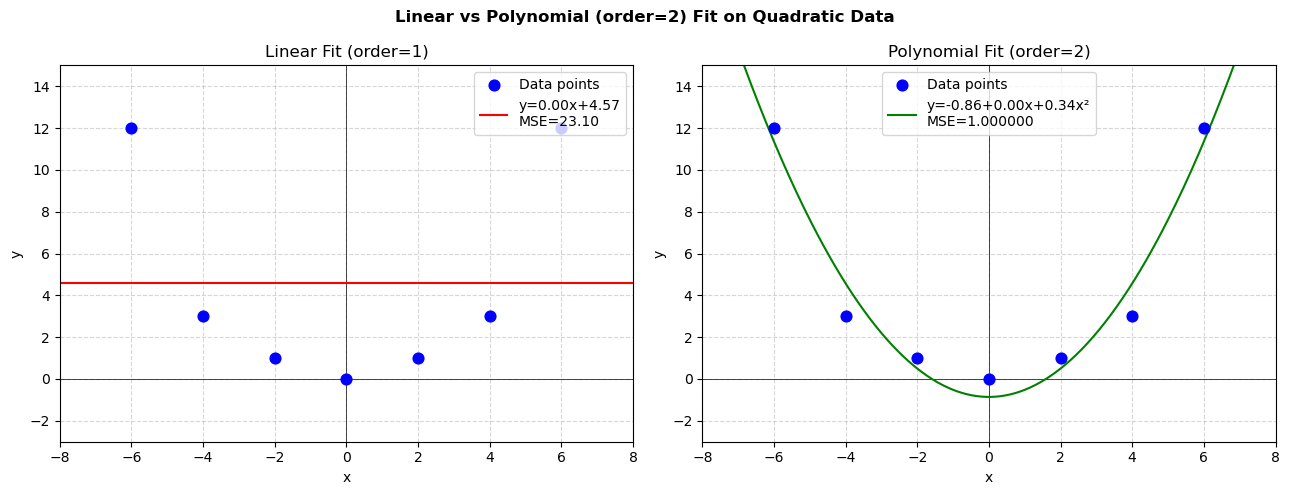

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ── Data ──
def data_quadratic():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[12], [3],  [1],  [0], [1], [3], [12]])
    return X, Y

# ── Polynomial basis transformation ──
def transform_polynomial_basis_1d(x, order):
    if order == 0:
        return [1]
    if order == 1:
        return [1, x]
    if order == 2:
        return [1, x, x**2]
    if order == 3:
        return [1, x, x**2, x**3]

# ── Transform full dataset ──
def transform_dataset(X, order):
    return np.array([transform_polynomial_basis_1d(x[0], order) for x in X])

# ── OLS closed-form ──
def ols_closed_form(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

# ── MSE ──
def mse(X, Y, theta):
    predictions = X @ theta
    residuals   = predictions - Y
    return float(np.mean(residuals ** 2))

# ── Load data ──
X, Y = data_quadratic()

# ── LINEAR fit (from part a, for comparison) ──
X_lin       = np.hstack([X, np.ones((X.shape[0], 1))])
theta_lin   = ols_closed_form(X_lin, Y)
mse_linear  = mse(X_lin, Y, theta_lin)

# ── POLYNOMIAL fit (order=2) ──
X_poly      = transform_dataset(X, order=2)      # shape: (7, 3)
theta_poly  = ols_closed_form(X_poly, Y)
mse_poly    = mse(X_poly, Y, theta_poly)

print(f"X_poly shape      : {X_poly.shape}  ← d=3 as expected")
print(f"\ntheta* (linear)   : {theta_lin.flatten().round(4)}")
print(f"MSE    (linear)   : {mse_linear:.4f}")
print(f"\ntheta* (order=2)  : {theta_poly.flatten().round(4)}")
print(f"  → y = {theta_poly[0,0]:.4f} + {theta_poly[1,0]:.4f}x + {theta_poly[2,0]:.4f}x²")
print(f"MSE    (order=2)  : {mse_poly:.6f}")
print(f"\nMSE improvement   : {mse_linear:.4f} → {mse_poly:.6f}  ({'better' if mse_poly < mse_linear else 'worse'})")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Linear vs Polynomial (order=2) Fit on Quadratic Data", fontweight='bold')

x_line = np.linspace(-8, 8, 300)

for ax, title in zip(axes, ["Linear Fit (order=1)", "Polynomial Fit (order=2)"]):
    ax.scatter(X, Y, color='blue', zorder=5, s=60, label='Data points')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(-8, 8); ax.set_ylim(-3, 15)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(color='black', linewidth=0.5)
    ax.axvline(color='black', linewidth=0.5)
    ax.set_title(title)

# Plot linear fit
y_linear = x_line * float(theta_lin[0]) + float(theta_lin[1])
axes[0].plot(x_line, y_linear, 'r-',
             label=f'y={theta_lin[0,0]:.2f}x+{theta_lin[1,0]:.2f}\nMSE={mse_linear:.2f}')
axes[0].legend()

# Plot polynomial fit (evaluate the parabola over x_line)
y_poly = theta_poly[0,0] + theta_poly[1,0]*x_line + theta_poly[2,0]*x_line**2
axes[1].plot(x_line, y_poly, 'g-',
             label=f'y={theta_poly[0,0]:.2f}+{theta_poly[1,0]:.2f}x+{theta_poly[2,0]:.2f}x²\nMSE={mse_poly:.6f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Q1.4(b)(iii)

theta* = [-8.57142857e-01  1.11022302e-16  3.39285714e-01]


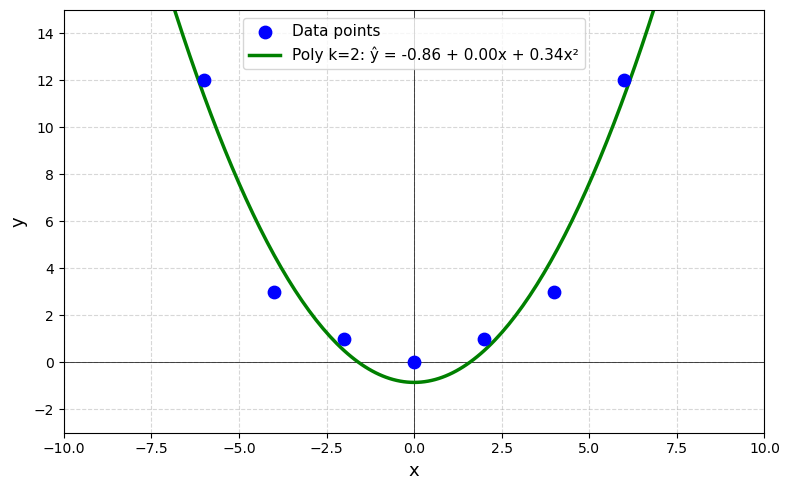

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Data
def data_quadratic():
    X = np.array([[-6], [-4], [-2], [0], [2], [4], [6]])
    Y = np.array([[12], [3],  [1],  [0], [1], [3], [12]])
    return X, Y

# Polynomial transformation
def transform_polynomial_basis_1d(x, order):
    if order == 0: return [1]
    if order == 1: return [1, x]
    if order == 2: return [1, x, x**2]
    if order == 3: return [1, x, x**2, x**3]

def transform_dataset(X, order):
    return np.array([transform_polynomial_basis_1d(x[0], order) for x in X])

# Setup: fit the model
X, Y = data_quadratic()
X_poly = transform_dataset(X, order=2)      
theta_star = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ Y

print(f"theta* = {theta_star.flatten()}")

x_plot = np.linspace(-10, 10, 201)           

X_plot_transformed = np.array([transform_polynomial_basis_1d(x, order=2) for x in x_plot])

y_plot = X_plot_transformed @ theta_star   

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_xlim(-10, 10)
ax.set_ylim(-3, 15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.axhline(color='black', linewidth=0.5)
ax.axvline(color='black', linewidth=0.5)

ax.scatter(X, Y, color='blue', zorder=5, s=80, label='Data points')

ax.plot(x_plot, y_plot, color='green', linewidth=2.5,
        label=f'Poly k=2: ŷ = {theta_star[0,0]:.2f} + {theta_star[1,0]:.2f}x + {theta_star[2,0]:.2f}x²')

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()